In [ ]:
#설치 필요 / colab에서는 생략 가능한 모듈도 있음
!pip install -q numpy pandas scikit-learn xgboost lightgbm catboost scikeras tensorflow matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.1 MB/s eta 0:00:00


In [ ]:
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple

from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# SciKeras (sklearn API로 Keras 모델 튜닝)
try:
    from scikeras.wrappers import KerasRegressor
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except Exception as e:
    KerasRegressor = None
    tf = None
    keras = None
    layers = None

np.random.seed(42)
pd.set_option('display.max_columns', 120)


In [ ]:
from google.colab import drive
import pandas as pd

# Google Drive 마운트
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# CSV 불러오기
df = pd.read_csv("/content/merged_data.csv")

print(df.head())

           일자  10센티미터(cm)  20센티미터(cm)  40센티미터(cm)  60센티미터(cm) 측정지점         위도  \
0  2024-01-01        43.4        50.1        37.6        46.6   안천  35.869421   
1  2024-01-02        42.6        49.9        38.6        46.7   안천  35.869421   
2  2024-01-03        42.4        49.6        38.7        46.7   안천  35.869421   
3  2024-01-04        42.3        49.6        38.6        46.7   안천  35.869421   
4  2024-01-05        41.8        49.4        38.4        46.7   안천  35.869421   

           경도  기온_DYTM_TMX  기온_MRNG_TMN  기온_NGHT_TMN  기온_TA_DAVG  기온_TMN_DD  \
0  127.543329          7.2         -1.6          1.1         2.7       -1.6   
1  127.543329          4.9          1.1         -0.3         2.6        1.1   
2  127.543329          3.3         -0.3         -6.2         0.8       -1.8   
3  127.543329          5.3         -6.2         -4.2        -1.2       -6.2   
4  127.543329          6.6         -4.2         -3.1         3.5       -4.2   

   기온_TMX_DD  강수량_RN_DSUM  강수량_RN_MAX_

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2196 entries, 0 to 2195
Data columns (total 53 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   일자               2196 non-null   object 
 1   10센티미터(cm)       2196 non-null   float64
 2   20센티미터(cm)       2196 non-null   float64
 3   40센티미터(cm)       2196 non-null   float64
 4   60센티미터(cm)       2196 non-null   float64
 5   측정지점             2196 non-null   object 
 6   위도               2196 non-null   float64
 7   경도               2196 non-null   float64
 8   기온_DYTM_TMX      2196 non-null   float64
 9   기온_MRNG_TMN      2196 non-null   float64
 10  기온_NGHT_TMN      2196 non-null   float64
 11  기온_TA_DAVG       2196 non-null   float64
 12  기온_TMN_DD        2196 non-null   float64
 13  기온_TMX_DD        2196 non-null   float64
 14  강수량_RN_DSUM      2196 non-null   float64
 15  강수량_RN_MAX_10M   2196 non-null   float64
 16  강수량_RN_MAX_1HR   2196 non-null   float64
 17  강수량_RN_MAX_6HR

In [ ]:
df[["10센티미터(cm)", "20센티미터(cm)", "40센티미터(cm)", "60센티미터(cm)"]].corr()

,10센티미터(cm),20센티미터(cm),40센티미터(cm),60센티미터(cm)
10센티미터(cm),1.000000,0.932658,0.901842,0.893512
20센티미터(cm),0.932658,1.000000,0.913826,0.941550
40센티미터(cm),0.901842,0.913826,1.000000,0.895306
60센티미터(cm),0.893512,0.941550,0.895306,1.000000


In [ ]:
df['일자'] = pd.to_datetime(df['일자'])
df = df.sort_values('일자').reset_index(drop=True)

In [ ]:
df.head()

,일자,10센티미터(cm),20센티미터(cm),40센티미터(cm),60센티미터(cm),측정지점,위도,경도,기온_DYTM_TMX,기온_MRNG_TMN,기온_NGHT_TMN,기온_TA_DAVG,기온_TMN_DD,기온_TMX_DD,강수량_RN_DSUM,강수량_RN_MAX_10M,강수량_RN_MAX_1HR,강수량_RN_MAX_6HR,기압_PA_MAVG,기압_PA_MAX,기압_PA_MIN,기압_PS_MAX,바람_WD_FRQ,바람_WD_INS_MAX,바람_WD_MAX,바람_WD_MIX,바람_WS_DAVG,바람_WS_INS_MAX,바람_WS_MAX,바람_WS_MIX,이슬점온도_TD_AVG,이슬점온도_TD_MAX,이슬점온도_TD_MIN,초상온도_TG_MIN,습도_RHM_AVG,습도_RHM_MIN,증기압_PV_DAVG,증기압_PV_MAX,증기압_PV_MIN,구름_CA_MAX,구름_LMAC_DAVG,구름_TCA_DAVG,시정_VS_MIN,적설_FSD_DMAX,적설_SD_DMAX,일사_GSR_DSUM,일사_SI_HR1_MAX,일조_SSRATE,일조_SS_HR_DSUM,증발량_LRG_EV_DSUM,증발량_SML_EV_DSUM,황사_PM10_DAVG,안개_FOG_DUR_DSUM
0,2024-01-01,43.4,50.1,37.6,46.6,안천,35.869421,127.543329,7.2,-1.6,1.1,2.7,-1.6,7.2,0.0,0.0,0.0,42.5,991.6,993.95,990.0,1030.4,225.0,222.2,212.9,199.7,1.1,4.5,3.2,0.0,0.7,2.1,-1.0,-5.1,83.0,57.6,6.5,7.1,5.7,10.0,4.0,5.1,16,0.0,0.0,8.0,1.7,24.5,2.4,1.1,1.5,21.0,0.0
1,2024-01-01,22.9,25.1,21.9,19.1,부귀,35.862286,127.399247,7.2,-1.6,1.1,2.7,-1.6,7.2,0.0,0.0,0.0,42.5,915.1,917.10,913.4,1031.9,225.0,222.2,212.9,199.7,1.1,4.5,3.2,0.0,0.7,1.6,-0.3,-4.3,83.0,57.6,6.4,6.9,6.0,9.0,4.0,4.4,307,0.0,0.0,8.0,1.7,65.3,6.4,1.1,1.5,21.0,0.0
2,2024-01-01,35.2,30.5,26.9,29.5,계북,35.808002,127.628078,-1.1,-7.0,-5.6,-4.2,-7.0,-1.1,0.0,0.0,0.0,69.5,852.8,854.60,850.8,1033.2,202.5,191.0,212.9,199.7,1.1,8.1,3.2,0.0,-0.4,1.0,-1.6,-4.3,98.0,94.5,5.9,6.6,5.4,9.0,1.0,2.0,15,0.0,0.0,8.0,1.7,34.7,3.4,1.1,1.5,21.0,0.0
3,2024-01-01,36.7,35.0,34.2,33.2,상전,35.805430,127.484713,7.5,-1.5,1.9,2.7,-1.5,7.5,0.0,0.0,0.0,0.0,977.4,979.60,976.0,1030.6,230.0,270.0,270.0,217.7,0.8,6.2,3.8,0.0,0.7,1.6,-0.3,-4.3,82.1,53.0,6.4,6.9,6.0,9.0,4.0,4.4,307,0.0,0.0,8.0,1.7,65.3,6.4,1.1,1.5,21.0,0.0
4,2024-01-01,31.2,29.9,29.2,30.3,주천,35.970598,127.423981,7.3,-1.0,2.3,2.7,-1.0,7.3,0.0,0.0,0.0,0.0,1005.8,1008.30,1004.0,1030.2,270.0,360.0,340.0,288.8,0.6,3.6,1.7,0.0,0.7,1.6,-0.3,-5.9,87.8,62.0,6.4,6.9,6.0,9.0,4.0,4.4,307,0.0,0.0,8.0,1.7,65.3,6.4,1.1,1.5,21.0,0.0


In [ ]:
targets = ["10센티미터(cm)", "20센티미터(cm)", "40센티미터(cm)", "60센티미터(cm)"]
df["target_avg"] = df[targets].mean(axis=1)

X = df.drop(columns=["일자","측정지점","위도","경도"] + targets + ["target_avg"])
y_dict = {t: df[t] for t in targets}
y_dict["target_avg"] = df["target_avg"]


In [ ]:
X

,기온_DYTM_TMX,기온_MRNG_TMN,기온_NGHT_TMN,기온_TA_DAVG,기온_TMN_DD,기온_TMX_DD,강수량_RN_DSUM,강수량_RN_MAX_10M,강수량_RN_MAX_1HR,강수량_RN_MAX_6HR,기압_PA_MAVG,기압_PA_MAX,기압_PA_MIN,기압_PS_MAX,바람_WD_FRQ,바람_WD_INS_MAX,바람_WD_MAX,바람_WD_MIX,바람_WS_DAVG,바람_WS_INS_MAX,바람_WS_MAX,바람_WS_MIX,이슬점온도_TD_AVG,이슬점온도_TD_MAX,이슬점온도_TD_MIN,초상온도_TG_MIN,습도_RHM_AVG,습도_RHM_MIN,증기압_PV_DAVG,증기압_PV_MAX,증기압_PV_MIN,구름_CA_MAX,구름_LMAC_DAVG,구름_TCA_DAVG,시정_VS_MIN,적설_FSD_DMAX,적설_SD_DMAX,일사_GSR_DSUM,일사_SI_HR1_MAX,일조_SSRATE,일조_SS_HR_DSUM,증발량_LRG_EV_DSUM,증발량_SML_EV_DSUM,황사_PM10_DAVG,안개_FOG_DUR_DSUM
0,7.2,-1.6,1.1,2.7,-1.6,7.2,0.0,0.0,0.0,42.5,991.60,993.95,990.00,1030.40,225.0,222.2,212.9,199.7,1.1,4.5,3.2,0.0,0.7,2.1,-1.0,-5.10,83.0,57.6,6.5,7.1,5.7,10.0,4.0,5.1,16,0.0,0.0,8.0,1.7,24.5,2.4,1.1,1.5,21.0,0.0
1,7.2,-1.6,1.1,2.7,-1.6,7.2,0.0,0.0,0.0,42.5,915.10,917.10,913.40,1031.90,225.0,222.2,212.9,199.7,1.1,4.5,3.2,0.0,0.7,1.6,-0.3,-4.30,83.0,57.6,6.4,6.9,6.0,9.0,4.0,4.4,307,0.0,0.0,8.0,1.7,65.3,6.4,1.1,1.5,21.0,0.0
2,-1.1,-7.0,-5.6,-4.2,-7.0,-1.1,0.0,0.0,0.0,69.5,852.80,854.60,850.80,1033.20,202.5,191.0,212.9,199.7,1.1,8.1,3.2,0.0,-0.4,1.0,-1.6,-4.30,98.0,94.5,5.9,6.6,5.4,9.0,1.0,2.0,15,0.0,0.0,8.0,1.7,34.7,3.4,1.1,1.5,21.0,0.0
3,7.5,-1.5,1.9,2.7,-1.5,7.5,0.0,0.0,0.0,0.0,977.40,979.60,976.00,1030.60,230.0,270.0,270.0,217.7,0.8,6.2,3.8,0.0,0.7,1.6,-0.3,-4.30,82.1,53.0,6.4,6.9,6.0,9.0,4.0,4.4,307,0.0,0.0,8.0,1.7,65.3,6.4,1.1,1.5,21.0,0.0
4,7.3,-1.0,2.3,2.7,-1.0,7.3,0.0,0.0,0.0,0.0,1005.80,1008.30,1004.00,1030.20,270.0,360.0,340.0,288.8,0.6,3.6,1.7,0.0,0.7,1.6,-0.3,-5.90,87.8,62.0,6.4,6.9,6.0,9.0,4.0,4.4,307,0.0,0.0,8.0,1.7,65.3,6.4,1.1,1.5,21.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2191,3.5,-2.2,-7.5,-4.1,-5.0,4.2,0.5,0.5,0.5,3.0,906.95,909.10,903.75,1025.40,247.5,250.3,244.3,233.8,2.3,7.4,5.1,1.0,-5.3,2.9,-9.3,-8.65,61.0,27.6,4.2,7.5,3.0,10.0,0.0,0.9,700,0.0,0.0,11.0,1.9,91.8,9.0,1.5,2.2,34.0,0.0
2192,-6.1,-10.6,-11.9,-8.1,-11.3,-3.1,0.5,0.5,0.5,3.0,842.60,844.50,840.00,1025.40,292.5,322.0,308.0,293.4,5.5,17.2,9.1,5.0,-7.6,0.4,-13.6,-8.65,81.0,52.7,3.5,6.3,2.1,10.0,0.0,0.9,1122,0.0,0.0,8.0,1.5,82.7,8.1,1.3,1.9,34.0,0.0
2193,3.5,-2.2,-7.5,0.8,-5.0,4.2,0.5,0.5,0.5,3.0,985.55,988.40,981.40,1025.35,247.5,250.3,244.3,233.8,2.3,7.4,5.1,1.0,-7.7,1.8,-11.5,-12.30,61.0,27.6,3.6,7.0,2.5,10.0,0.0,0.9,1040,0.0,0.0,11.0,1.9,91.8,9.0,1.5,2.2,34.0,0.0
2194,3.7,-0.4,-7.6,-0.1,-6.4,5.0,0.0,0.0,0.0,0.0,971.30,973.70,967.50,1025.40,320.0,320.0,320.0,335.2,2.3,11.5,5.4,2.0,-5.3,2.9,-9.3,-11.40,59.6,27.0,4.2,7.5,3.0,10.0,0.0,0.9,700,0.0,0.0,11.0,1.9,91.8,9.0,1.5,2.2,34.0,0.0


In [ ]:
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_dict = {k: v.iloc[:split_idx] for k,v in y_dict.items()}
y_test_dict  = {k: v.iloc[split_idx:] for k,v in y_dict.items()}


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

num_cols = X_train.select_dtypes(include=["float64","int64"]).columns
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols)
])


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestRegressor(n_estimators=300, random_state=42))
])

for tgt in targets + ["target_avg"]:
    model.fit(X_train, y_train_dict[tgt])
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test_dict[tgt], preds)
    mse = mean_squared_error(y_test_dict[tgt], preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_dict[tgt], preds)
    print(f"{tgt} → MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")


10센티미터(cm) → MAE: 2.715, RMSE: 3.366, R2: 0.749
20센티미터(cm) → MAE: 2.995, RMSE: 3.713, R2: 0.806
40센티미터(cm) → MAE: 3.545, RMSE: 4.503, R2: 0.550
60센티미터(cm) → MAE: 2.954, RMSE: 4.027, R2: 0.825
target_avg → MAE: 2.854, RMSE: 3.565, R2: 0.782


모델 학습 파일 업로드 시 스킵 가능

In [ ]:
import os, json
import numpy as np
import pandas as pd
from pathlib import Path
from joblib import dump
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import math, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import GridSearchCV, KFold, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    xgb_available = True
except Exception:
    xgb_available = False

try:
    from lightgbm import LGBMRegressor
    lgb_available = True
except Exception:
    lgb_available = False

try:
    from catboost import CatBoostRegressor
    cb_available = True
except Exception:
    cb_available = False


try:
    from google.colab import files as colab_files
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    colab_files = None


# X_train, X_test, y_train_dict, y_test_dict, preprocessor, targets, models_and_grids
cv = TimeSeriesSplit(n_splits=3)  # 시계열


models_and_grids = []

# 선형 계열
models_and_grids.append((
    "LinearRegression",
    Pipeline([("prep", preprocessor), ("model", LinearRegression())]),
    {"model__fit_intercept": [True, False]}
))

models_and_grids.append((
    "Ridge",
    Pipeline([("prep", preprocessor), ("model", Ridge(random_state=42))]),
    {"model__alpha": [0.1, 1.0, 10.0, 100.0]}
))

models_and_grids.append((
    "Lasso",
    Pipeline([("prep", preprocessor), ("model", Lasso(random_state=42, max_iter=10000))]),
    {"model__alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]}
))

models_and_grids.append((
    "ElasticNet",
    Pipeline([("prep", preprocessor), ("model", ElasticNet(random_state=42, max_iter=10000))]),
    {"model__alpha": [0.0005, 0.005, 0.05, 0.5],
     "model__l1_ratio": [0.2, 0.5, 0.8]}
))

# 트리/부스팅
models_and_grids.append((
    "RandomForest",
    Pipeline([("prep", preprocessor), ("model", RandomForestRegressor(random_state=42, n_jobs=-1))]),
    {"model__n_estimators": [300, 600],
     "model__max_depth": [None, 8, 12],
     "model__min_samples_leaf": [1, 3, 5]}
))

models_and_grids.append((
    "GradientBoosting",
    Pipeline([("prep", preprocessor), ("model", GradientBoostingRegressor(random_state=42))]),
    {"model__n_estimators": [300, 600],
     "model__learning_rate": [0.05, 0.1],
     "model__max_depth": [2, 3, 4]}
))

if xgb_available:
    models_and_grids.append((
        "XGBoost",
        Pipeline([("prep", preprocessor), ("model", XGBRegressor(random_state=42, n_jobs=-1, objective="reg:squarederror"))]),
        {"model__n_estimators": [400, 800],
         "model__max_depth": [3, 5, 7],
         "model__learning_rate": [0.05, 0.1],
         "model__subsample": [0.7, 1.0],
         "model__colsample_bytree": [0.7, 1.0]}
    ))

if lgb_available:
    models_and_grids.append((
        "LightGBM",
        Pipeline([("prep", preprocessor), ("model", LGBMRegressor(random_state=42, n_jobs=-1))]),
        {"model__n_estimators": [400, 800],
         "model__num_leaves": [31, 63, 127],
         "model__learning_rate": [0.05, 0.1],
         "model__max_depth": [-1, 8, 12]}
    ))

if cb_available:
    models_and_grids.append((
        "CatBoost",
        Pipeline([("prep", preprocessor), ("model", CatBoostRegressor(random_state=42, verbose=False))]),
        {"model__iterations": [800, 1200],
         "model__depth": [4, 6, 8],
         "model__learning_rate": [0.05, 0.1],
         "model__l2_leaf_reg": [1, 3, 5]}
    ))



# ========= 저장 폴더 =========
BASE_DIR = Path("./artifacts_live")
MODELS_DIR = BASE_DIR / "models"
CV_DIR = BASE_DIR / "cv"
RESULTS_DIR = BASE_DIR / "results"
for d in [MODELS_DIR, CV_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RESULTS_CSV = RESULTS_DIR / "results_log.csv"
if not RESULTS_CSV.exists():
    pd.DataFrame(columns=[
        "timestamp","target","model","cv_scoring",
        "cv_best_score_negMSE","cv_best_RMSE_est",
        "test_MAE","test_RMSE","test_R2","best_params",
        "model_path","cv_path"
    ]).to_csv(RESULTS_CSV, index=False)

def safe_name(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in "._-()" else "_" for ch in str(s))

def append_result(row: dict, csv_path=RESULTS_CSV):
    pd.DataFrame([row]).to_csv(csv_path, mode="a", header=False, index=False)


results = []
target_loop = targets + ["target_avg"]

for tgt in target_loop:
    y_train = y_train_dict[tgt]
    y_test  = y_test_dict[tgt]
    print(f"\n========== Target: {tgt} ==========")

    for name, pipe, grid in models_and_grids:
        print(f"[GridSearch] {name} ...")


        gs = GridSearchCV(
            estimator=pipe,
            param_grid=grid,
            cv=cv,
            n_jobs=-1,
            verbose=0,
            scoring="neg_mean_squared_error"
        )
        gs.fit(X_train, y_train)


        pred  = gs.best_estimator_.predict(X_test)
        mae   = mean_absolute_error(y_test, pred)
        mse   = mean_squared_error(y_test, pred)
        rmse  = float(np.sqrt(mse))
        r2    = r2_score(y_test, pred)


        cv_neg_mse  = float(gs.best_score_)
        cv_rmse_est = float(np.sqrt(-cv_neg_mse))

        print(f" -> Test MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f} | BestParams: {gs.best_params_}")

        model_fname = f"best_{safe_name(tgt)}_{safe_name(name)}.joblib"
        model_fpath = MODELS_DIR / model_fname

        cv_fname = f"cv_{safe_name(tgt)}_{safe_name(name)}.csv"
        cv_fpath = CV_DIR / cv_fname

        # ===== 1) 모델 저장 (전처리 포함 파이프라인 통째로) =====
        dump(gs.best_estimator_, model_fpath)

        # ===== 2) CV 결과 저장 =====
        pd.DataFrame(gs.cv_results_).to_csv(cv_fpath, index=False)

        # ===== 3) 요약 로그 한 줄 추가 =====
        row = {
            "timestamp": pd.Timestamp.now(tz="Asia/Seoul").isoformat(),
            "target": tgt,
            "model": name,
            "cv_scoring": "neg_mean_squared_error",
            "cv_best_score_negMSE": cv_neg_mse,
            "cv_best_RMSE_est": cv_rmse_est,
            "test_MAE": float(mae),
            "test_RMSE": rmse,
            "test_R2": float(r2),
            "best_params": json.dumps(gs.best_params_, ensure_ascii=False),
            "model_path": str(model_fpath),
            "cv_path": str(cv_fpath),
        }
        append_result(row)


        if IN_COLAB:
            try:
                print("   - 다운로드: 모델 파일")
                colab_files.download(str(model_fpath))
            except Exception as e:
                print("   - 모델 다운로드 오류:", e)
            try:
                print("   - 다운로드: CV 결과 CSV")
                colab_files.download(str(cv_fpath))
            except Exception as e:
                print("   - CV 다운로드 오류:", e)





========== Target: 10센티미터(cm) ==========
[GridSearch] LinearRegression ...
 -> Test MAE: 6.4698 | RMSE: 12.8785 | R2: -2.6674 | BestParams: {'model__fit_intercept': True}
   - 다운로드: 모델 파일


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   - 다운로드: CV 결과 CSV


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   - 다운로드: CV 결과 CSV


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
res_df = pd.read_csv("/content/artifacts_live/results/results_log.csv")

display(res_df.sort_values(["target","test_RMSE"]).head(20))

# 타겟별 Best (RMSE 최소)
best_by_target = res_df.sort_values(["target","test_RMSE"]).groupby("target", as_index=False).first()
print("\n=== 타겟별 Best Model (Test RMSE 기준) ===")
display(best_by_target[["target","model","test_MAE","test_RMSE","test_R2","best_params"]])

# 모델별로 '개별 타겟 평균 vs 평균 타겟' 성능 비교
indiv_mean = res_df[res_df["target"]!="target_avg"].groupby("model")[["test_MAE","test_RMSE","test_R2"]].mean().add_suffix("_indiv_mean")
avg_only  = res_df[res_df["target"]=="target_avg"][["model","test_MAE","test_RMSE","test_R2"]].set_index("model").add_suffix("_avg_target")
compare = indiv_mean.join(avg_only, how="inner")
print("\n=== 개별 타겟 평균 vs 평균 타겟 성능 비교 (모델별) ===")
display(compare.sort_values("test_RMSE_avg_target"))


,timestamp,target,model,cv_scoring,cv_best_score_negMSE,cv_best_RMSE_est,test_MAE,test_RMSE,test_R2,best_params,model_path,cv_path
6,2025-08-23T09:15:26.907996+09:00,10센티미터(cm),XGBoost,neg_mean_squared_error,-49.510928,7.036400,2.565947,3.324934,0.755547,"{""model__colsample_bytree"": 1.0, ""model__learn...",artifacts_live/models/best_10센티미터(cm)_XGBoost....,artifacts_live/cv/cv_10센티미터(cm)_XGBoost.csv
4,2025-08-23T09:07:13.607542+09:00,10센티미터(cm),RandomForest,neg_mean_squared_error,-50.217011,7.086396,2.715514,3.359426,0.750449,"{""model__max_depth"": null, ""model__min_samples...",artifacts_live/models/best_10센티미터(cm)_RandomFo...,artifacts_live/cv/cv_10센티미터(cm)_RandomForest.csv
8,2025-08-23T09:57:31.116109+09:00,10센티미터(cm),CatBoost,neg_mean_squared_error,-49.942217,7.066981,2.700173,3.380827,0.747259,"{""model__depth"": 8, ""model__iterations"": 1200,...",artifacts_live/models/best_10센티미터(cm)_CatBoost...,artifacts_live/cv/cv_10센티미터(cm)_CatBoost.csv
7,2025-08-23T09:32:41.334959+09:00,10센티미터(cm),LightGBM,neg_mean_squared_error,-54.663762,7.393495,2.653357,3.413494,0.742351,"{""model__learning_rate"": 0.1, ""model__max_dept...",artifacts_live/models/best_10센티미터(cm)_LightGBM...,artifacts_live/cv/cv_10센티미터(cm)_LightGBM.csv
5,2025-08-23T09:09:28.194357+09:00,10센티미터(cm),GradientBoosting,neg_mean_squared_error,-57.621385,7.590875,3.254681,4.115318,0.625513,"{""model__learning_rate"": 0.05, ""model__max_dep...",artifacts_live/models/best_10센티미터(cm)_Gradient...,artifacts_live/cv/cv_10센티미터(cm)_GradientBoosti...
3,2025-08-23T08:59:24.051714+09:00,10센티미터(cm),ElasticNet,neg_mean_squared_error,-73.489774,8.572618,5.251152,6.148760,0.164003,"{""model__alpha"": 0.5, ""model__l1_ratio"": 0.8}",artifacts_live/models/best_10센티미터(cm)_ElasticN...,artifacts_live/cv/cv_10센티미터(cm)_ElasticNet.csv
2,2025-08-23T08:59:21.349395+09:00,10센티미터(cm),Lasso,neg_mean_squared_error,-76.800145,8.763569,5.580536,7.856197,-0.364754,"{""model__alpha"": 0.1}",artifacts_live/models/best_10센티미터(cm)_Lasso.jo...,artifacts_live/cv/cv_10센티미터(cm)_Lasso.csv
1,2025-08-23T08:59:19.072162+09:00,10센티미터(cm),Ridge,neg_mean_squared_error,-76.734828,8.759842,6.292363,10.799298,-1.578818,"{""model__alpha"": 100.0}",artifacts_live/models/best_10센티미터(cm)_Ridge.jo...,artifacts_live/cv/cv_10센티미터(cm)_Ridge.csv
0,2025-08-23T08:59:18.482654+09:00,10센티미터(cm),LinearRegression,neg_mean_squared_error,-92.594477,9.622602,6.469848,12.878515,-2.667425,"{""model__fit_intercept"": true}",artifacts_live/models/best_10센티미터(cm)_LinearRe...,artifacts_live/cv/cv_10센티미터(cm)_LinearRegressi...
14,2025-08-23T10:07:57.739951+09:00,20센티미터(cm),GradientBoosting,neg_mean_squared_error,-58.359345,7.639329,2.543624,3.201121,0.855983,"{""model__learning_rate"": 0.1, ""model__max_dept...",artifacts_live/models/best_20센티미터(cm)_Gradient...,artifacts_live/cv/cv_20센티미터(cm)_GradientBoosti...



=== 타겟별 Best Model (Test RMSE 기준) ===


,target,model,test_MAE,test_RMSE,test_R2,best_params
0,10센티미터(cm),XGBoost,2.565947,3.324934,0.755547,"{""model__colsample_bytree"": 1.0, ""model__learn..."
1,20센티미터(cm),GradientBoosting,2.543624,3.201121,0.855983,"{""model__learning_rate"": 0.1, ""model__max_dept..."
2,40센티미터(cm),CatBoost,3.332505,4.317719,0.585842,"{""model__depth"": 6, ""model__iterations"": 800, ..."
3,60센티미터(cm),CatBoost,2.489825,3.257762,0.885702,"{""model__depth"": 6, ""model__iterations"": 800, ..."
4,target_avg,XGBoost,2.476347,3.235273,0.820386,"{""model__colsample_bytree"": 1.0, ""model__learn..."



=== 개별 타겟 평균 vs 평균 타겟 성능 비교 (모델별) ===


,test_MAE_indiv_mean,test_RMSE_indiv_mean,test_R2_indiv_mean,test_MAE_avg_target,test_RMSE_avg_target,test_R2_avg_target
model,,,,,,
XGBoost,2.738724,3.585324,0.765654,2.476347,3.235273,0.820386
GradientBoosting,3.015757,3.873545,0.725462,2.623030,3.248788,0.818882
CatBoost,2.777646,3.557010,0.767091,2.632421,3.335663,0.809066
LightGBM,2.830775,3.743295,0.747054,2.623723,3.367982,0.805348
RandomForest,3.054641,3.908124,0.732021,2.870211,3.582874,0.779717
ElasticNet,6.138972,7.709248,0.055810,5.841970,6.676981,0.234970
Lasso,6.061501,7.634102,0.035006,5.973014,7.361143,0.070158
Ridge,6.787887,10.315095,-0.772587,6.686469,10.098587,-0.750006
LinearRegression,7.060825,12.406592,-1.568258,6.941504,12.231401,-1.567266



=== Permutation Importance: XGBoost | Target: 10센티미터(cm) ===


,feature,importance_mean,importance_std
11,num__기압_PA_MAX,0.842124,0.028809
12,num__기압_PA_MIN,0.186688,0.011688
9,num__강수량_RN_MAX_6HR,0.087229,0.013660
18,num__바람_WS_DAVG,0.077213,0.004829
10,num__기압_PA_MAVG,0.062137,0.005517
24,num__이슬점온도_TD_MIN,0.035136,0.002627
19,num__바람_WS_INS_MAX,0.027721,0.003578
34,num__시정_VS_MIN,0.017652,0.002247
13,num__기압_PS_MAX,0.012447,0.003385
39,num__일조_SSRATE,0.011082,0.002339


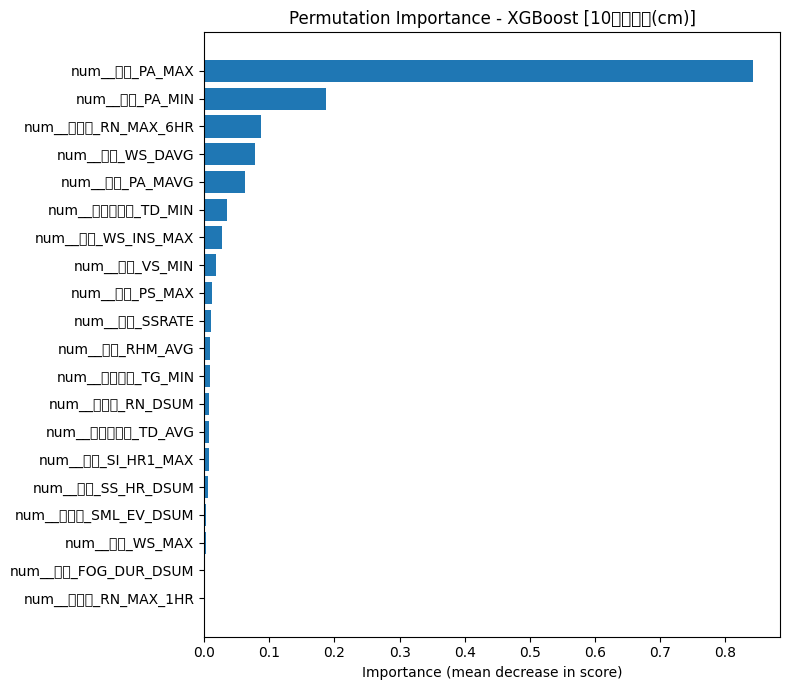


=== Permutation Importance: GradientBoosting | Target: 20센티미터(cm) ===


,feature,importance_mean,importance_std
11,num__기압_PA_MAX,0.737440,0.020990
12,num__기압_PA_MIN,0.369697,0.026491
10,num__기압_PA_MAVG,0.175041,0.014076
13,num__기압_PS_MAX,0.114298,0.011057
18,num__바람_WS_DAVG,0.112089,0.007729
9,num__강수량_RN_MAX_6HR,0.060010,0.014542
19,num__바람_WS_INS_MAX,0.054121,0.003879
24,num__이슬점온도_TD_MIN,0.016851,0.001721
22,num__이슬점온도_TD_AVG,0.008673,0.002198
20,num__바람_WS_MAX,0.008091,0.001718


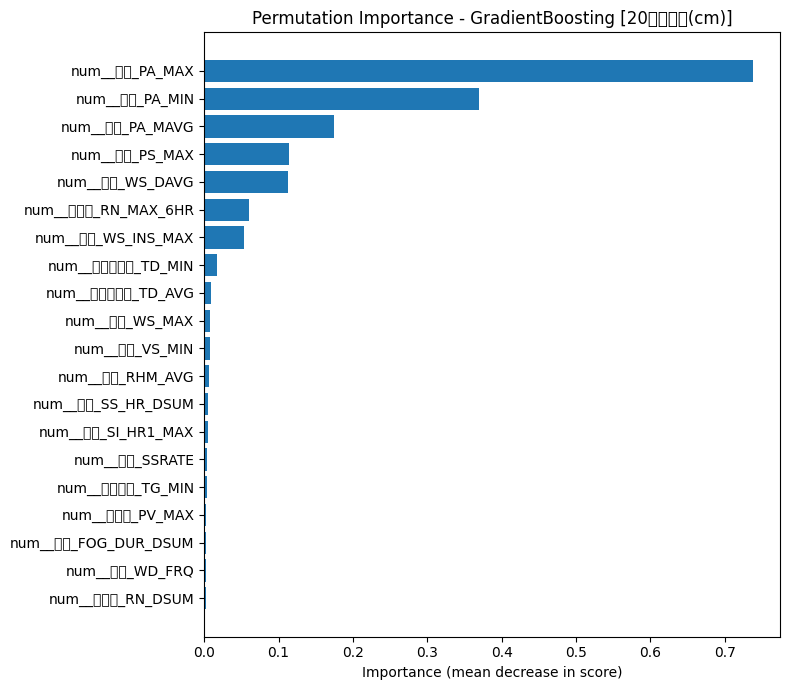


=== Permutation Importance: CatBoost | Target: 40센티미터(cm) ===


,feature,importance_mean,importance_std
11,num__기압_PA_MAX,0.226034,0.015860
12,num__기압_PA_MIN,0.164879,0.014470
10,num__기압_PA_MAVG,0.122061,0.014549
34,num__시정_VS_MIN,0.044728,0.008456
9,num__강수량_RN_MAX_6HR,0.043136,0.009037
18,num__바람_WS_DAVG,0.033303,0.008526
39,num__일조_SSRATE,0.022755,0.003529
13,num__기압_PS_MAX,0.016437,0.004026
38,num__일사_SI_HR1_MAX,0.015478,0.002706
19,num__바람_WS_INS_MAX,0.013795,0.001668


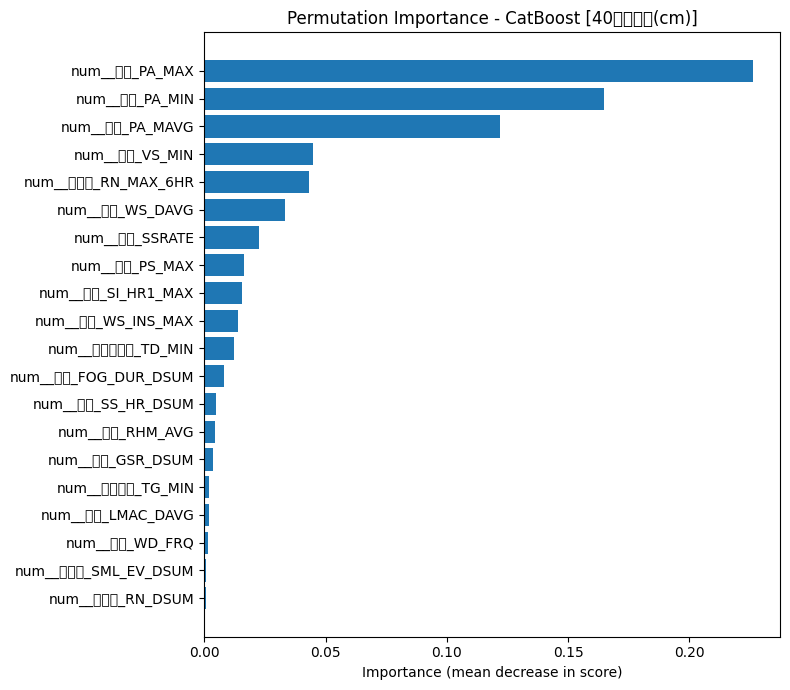

CatBoostError: You can't change params of fitted model.

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from ast import literal_eval

tree_like = {"RandomForest","GradientBoosting","XGBoost","LightGBM","CatBoost"}

# 타겟별 베스트 중 트리계열만 추려서 중요도 계산
for _, row in best_by_target.iterrows():
    tgt = row["target"]
    model_name = row["model"]
    if model_name not in tree_like:
        continue

    # 해당 모델 파이프라인 재생성 + 베스트 파라미터 적용
    # (위의 models_and_grids에서 동일 모델명 찾아서 파이프라인 꺼내기)
    for name, pipe, grid in models_and_grids:
        if name == model_name:
            best_pipe = Pipeline(steps=pipe.steps)
            for k, v in literal_eval(row["best_params"]).items():
                best_pipe.set_params(**{k: v})
            break


    y_train = y_train_dict[tgt]
    y_test  = y_test_dict[tgt]

    best_pipe.fit(X_train, y_train)
    perm = permutation_importance(
        best_pipe, X_test, y_test,
        n_repeats=5, random_state=42, n_jobs=-1
    )

    feat_names = best_pipe.named_steps["prep"].get_feature_names_out()
    imp_df = pd.DataFrame({
        "feature": feat_names,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False)

    top_k = 20
    top_imp = imp_df.head(top_k)

    print(f"\n=== Permutation Importance: {model_name} | Target: {tgt} ===")
    display(top_imp)

    # 수평 바차트 (색상 지정 X)
    fig, ax = plt.subplots(figsize=(8, max(4, len(top_imp)*0.35)))
    ax.barh(top_imp["feature"], top_imp["importance_mean"])
    ax.set_xlabel("Importance (mean decrease in score)")
    ax.set_title(f"Permutation Importance - {model_name} [{tgt}]")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
from joblib import load

tgt = "20센티미터(cm)"
pipe_best = load(f"./artifacts_live/models/best_{tgt}_GradientBoosting.joblib")
pressure_cols = [c for c in ["기압_PA_MAVG","기압_PA_MAX","기압_PA_MIN","기압_PS_MAX"] if c in X_test.columns]

base_r2 = pipe_best.score(X_test, y_test_dict[tgt])

def group_perm_drop(pipe, X, y, cols, n_repeats=20):
    drops = []
    for _ in range(n_repeats):
        Xp = X.copy()
        idx = np.random.permutation(len(Xp))
        Xp.loc[:, cols] = Xp[cols].values[idx]
        drops.append(base_r2 - pipe.score(Xp, y))
    return float(np.mean(drops)), float(np.std(drops))

drop_mean, drop_std = group_perm_drop(pipe_best, X_test, y_test_dict[tgt], pressure_cols)
print(f"[Group PI] pressure ΔR2 = {drop_mean:.3f} ± {drop_std:.3f}")


[Group PI] pressure ΔR2 = 1.626 ± 0.102


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

Xtr_noP = X_train.drop(columns=[c for c in pressure_cols if c in X_train.columns])
Xte_noP = X_test.drop(columns=[c for c in pressure_cols if c in X_test.columns])

def make_pre(X):
    nums = X.select_dtypes(include=["float64","float32","int64","int32"]).columns
    return ColumnTransformer([("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), nums)])

pre_noP = make_pre(Xtr_noP)

# 원래 최적 GBDT 파라미터 재사용
gb_params = pipe_best.named_steps["model"].get_params()
pipe_noP = Pipeline([("prep", pre_noP), ("model", GradientBoostingRegressor(**gb_params))]).fit(Xtr_noP, y_train_dict[tgt])

pred_org = pipe_best.predict(X_test)
pred_noP = pipe_noP.predict(Xte_noP)

rmse_org = np.sqrt(mean_squared_error(y_test_dict[tgt], pred_org))
rmse_noP = np.sqrt(mean_squared_error(y_test_dict[tgt], pred_noP))
r2_org   = r2_score(y_test_dict[tgt], pred_org)
r2_noP   = r2_score(y_test_dict[tgt], pred_noP)

print(f"[원본]  RMSE={rmse_org:.3f}, R2={r2_org:.3f}")
print(f"[무기압] RMSE={rmse_noP:.3f}, R2={r2_noP:.3f}")
print(f"ΔRMSE={rmse_noP-rmse_org:.3f} ,  ΔR2={r2_noP-r2_org:.3f}")


[원본]  RMSE=3.201, R2=0.856
[무기압] RMSE=8.370, R2=0.015
ΔRMSE=5.169 (↑면 기압 유효),  ΔR2=-0.841 (↓면 기압 유효)
